# Matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Visualization with Matplotlib

We'll now take an in-depth look at the Matplotlib package for visualization in Python.
Matplotlib is a multi-platform data visualization library built on NumPy arrays, and designed to work with the broader SciPy stack.
It was conceived by John Hunter in 2002, originally as a patch to IPython for enabling interactive MATLAB-style plotting via gnuplot from the IPython command line.
IPython's creator, Fernando Perez, was at the time scrambling to finish his PhD, and let John know he wouldn’t have time to review the patch for several months.
John took this as a cue to set out on his own, and the Matplotlib package was born, with version 0.1 released in 2003.
It received an early boost when it was adopted as the plotting package of choice of the Space Telescope Science Institute (the folks behind the Hubble Telescope), which financially supported Matplotlib’s development and greatly expanded its capabilities.

One of Matplotlib’s most important features is its ability to play well with many operating systems and graphics backends.
Matplotlib supports dozens of backends and output types, which means you can count on it to work regardless of which operating system you are using or which output format you wish.
This cross-platform, everything-to-everyone approach has been one of the great strengths of Matplotlib.
It has led to a large user base, which in turn has led to an active developer base and Matplotlib’s powerful tools and ubiquity within the scientific Python world.

In recent years, however, the interface and style of Matplotlib have begun to show their age.
Newer tools like ggplot and ggvis in the R language, along with web visualization toolkits based on D3js and HTML5 canvas, often make Matplotlib feel clunky and old-fashioned.
Still, I'm of the opinion that we cannot ignore Matplotlib's strength as a well-tested, cross-platform graphics engine.
Recent Matplotlib versions make it relatively easy to set new global plotting styles (see [Customizing Matplotlib: Configurations and Style Sheets](04.11-Settings-and-Stylesheets.ipynb)), and people have been developing new packages that build on its powerful internals to drive Matplotlib via cleaner, more modern APIs—for example, Seaborn (discussed in [Visualization With Seaborn](04.14-Visualization-With-Seaborn.ipynb)), [ggpy](http://yhat.github.io/ggpy/), [HoloViews](http://holoviews.org/), [Altair](http://altair-viz.github.io/), and even Pandas itself can be used as wrappers around Matplotlib's API.
Even with wrappers like these, it is still often useful to dive into Matplotlib's syntax to adjust the final plot output.
For this reason, I believe that Matplotlib itself will remain a vital piece of the data visualization stack, even if new tools mean the community gradually moves away from using the Matplotlib API directly.

In [3]:
plt.style.use('classic')


#### Plotting from an IPython notebook

The IPython notebook is a browser-based interactive data analysis tool that can combine narrative, code, graphics, HTML elements, and much more into a single executable document (see [IPython: Beyond Normal Python](01.00-IPython-Beyond-Normal-Python.ipynb)).

Plotting interactively within an IPython notebook can be done with the ``%matplotlib`` command, and works in a similar way to the IPython shell.
In the IPython notebook, you also have the option of embedding graphics directly in the notebook, with two possible options:

- ``%matplotlib notebook`` will lead to *interactive* plots embedded within the notebook
- ``%matplotlib inline`` will lead to *static* images of your plot embedded in the notebook

For this book, we will generally opt for ``%matplotlib inline``:

In [10]:
%matplotlib inline


After running this command (it needs to be done only once per kernel/session), any cell within the notebook that creates a plot will embed a PNG image of the resulting graphic:

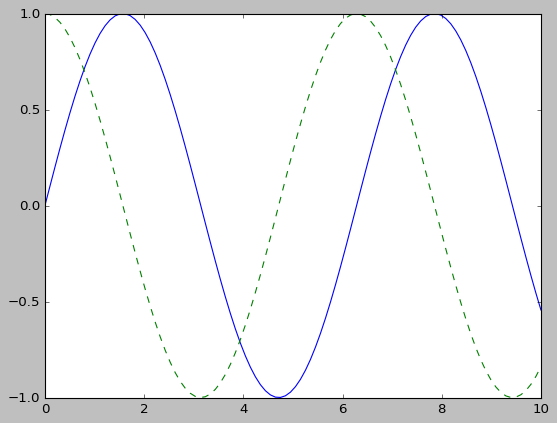

In [4]:
import numpy as np
x = np.linspace(0, 10, 100)

fig = plt.figure()
plt.plot(x, np.sin(x), '-')
plt.plot(x, np.cos(x), '--')

plt.show()

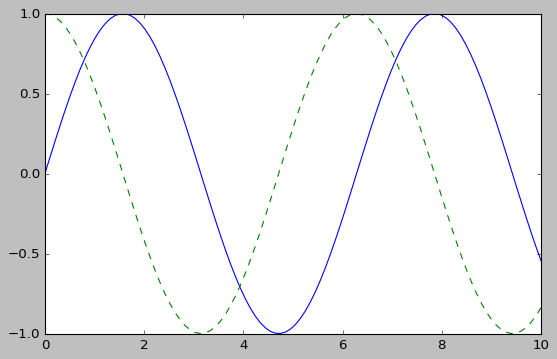

In [39]:
x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(x, np.sin(x), '-')
ax.plot(x, np.cos(x), '--')

plt.show()


In [35]:
fig.savefig('my_figure.png')


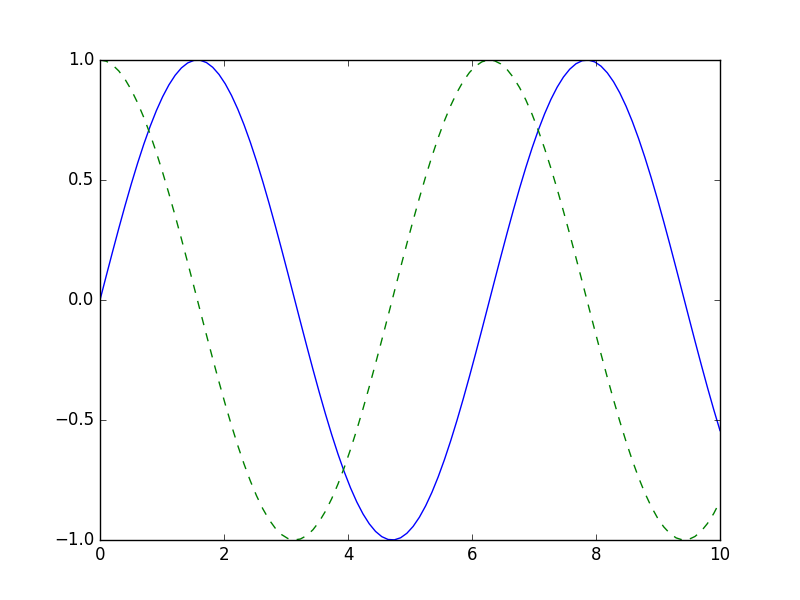

In [36]:
from IPython.display import Image
Image('my_figure.png')

In ``savefig()``, the file format is inferred from the extension of the given filename.
Depending on what backends you have installed, many different file formats are available.
The list of supported file types can be found for your system by using the following method of the figure canvas object:

In [7]:
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

## Two Interfaces for the Price of One

A potentially confusing feature of Matplotlib is its dual interfaces: a convenient MATLAB-style state-based interface, and a more powerful object-oriented interface. We'll quickly highlight the differences between the two here.

#### MATLAB-style Interface

Matplotlib was originally written as a Python alternative for MATLAB users, and much of its syntax reflects that fact.
The MATLAB-style tools are contained in the pyplot (``plt``) interface.
For example, the following code will probably look quite familiar to MATLAB users:

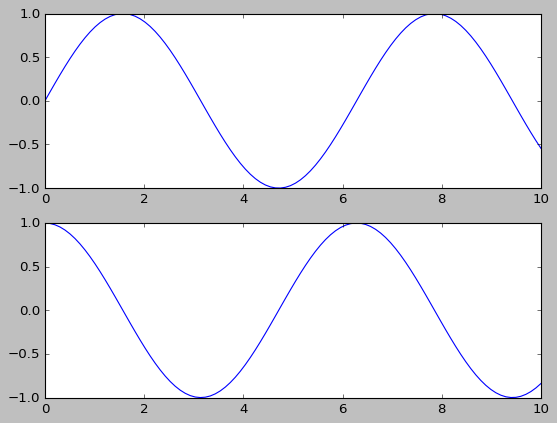

In [8]:
plt.figure()  # create a plot figure

# create the first of two panels and set current axis
plt.subplot(2, 1, 1) # (rows, columns, panel number)
plt.plot(x, np.sin(x))

# create the second panel and set current axis
plt.subplot(2, 1, 2)
plt.plot(x, np.cos(x));

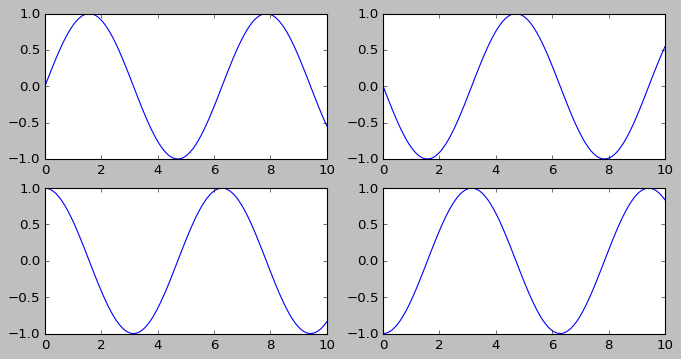

In [13]:
plt.figure(figsize=(10,5))  # create a plot figure

# create the first of two panels and set current axis
plt.subplot(2, 2, 1) # (rows, columns, panel number)
plt.plot(x, np.sin(x))

plt.subplot(2, 2, 2) # (rows, columns, panel number)
plt.plot(x, np.sin(x + np.pi))

# create the second panel and set current axis
plt.subplot(2, 2, 3)
plt.plot(x, np.cos(x))

plt.subplot(2, 2, 4)
plt.plot(x, np.cos(x + np.pi));

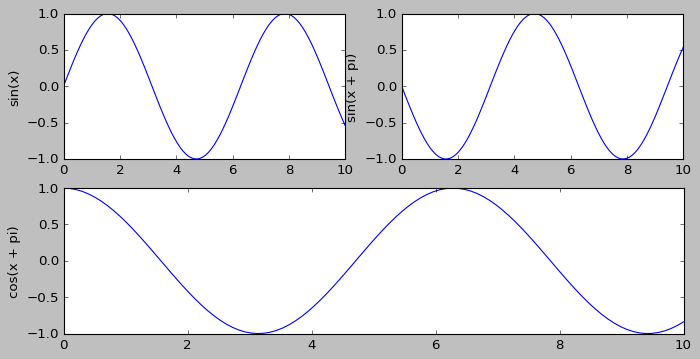

In [19]:
plt.figure(figsize=(10,5))  # create a plot figure

# create the first of two panels and set current axis
plt.subplot(2, 2, 1) # (rows, columns, panel number)
plt.plot(x, np.sin(x))
plt.ylabel("sin(x)")

plt.subplot(2, 2, 2) # (rows, columns, panel number)
plt.plot(x, np.sin(x + np.pi))
plt.ylabel("sin(x + pi)")

plt.subplot(2, 1, 2)
plt.plot(x, np.cos(x))
plt.ylabel("cos(x + pi)");

#### Object-oriented interface

The object-oriented interface is available for these more complicated situations, and for when you want more control over your figure.
Rather than depending on some notion of an "active" figure or axes, in the object-oriented interface the plotting functions are *methods* of explicit ``Figure`` and ``Axes`` objects.
To re-create the previous plot using this style of plotting, you might do the following:

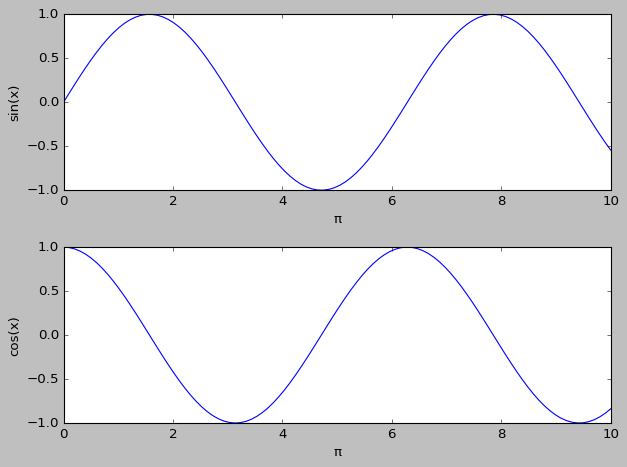

In [32]:
fig, ax = plt.subplots(2)

# Call plot() method on the appropriate object
ax[0].plot(x, np.sin(x))
ax[0].set_xlabel("π")
ax[0].set_ylabel("sin(x)")

ax[1].plot(x, np.cos(x))
ax[1].set_xlabel("π")
ax[1].set_ylabel("cos(x)")

fig.tight_layout();


Perhaps the simplest of all plots is the visualization of a single function $y = f(x)$.
Here we will take a first look at creating a simple plot of this type.
As with all the following sections, we'll start by setting up the notebook for plotting and  importing the packages we will use:

In [45]:
%matplotlib inline
plt.style.use('bmh')


Perhaps the simplest of all plots is the visualization of a single function $y = f(x)$.
Here we will take a first look at creating a simple plot of this type.
As with all the following sections, we'll start by setting up the notebook for plotting and  importing the packages we will use:

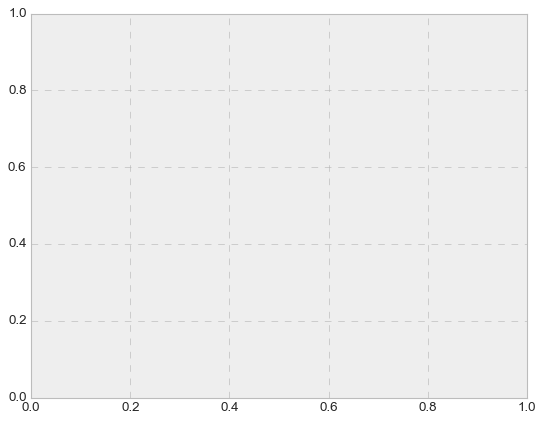

In [46]:
fig = plt.figure()
ax = plt.axes()

In Matplotlib, the *figure* (an instance of the class ``plt.Figure``) can be thought of as a single container that contains all the objects representing axes, graphics, text, and labels.
The *axes* (an instance of the class ``plt.Axes``) is what we see above: a bounding box with ticks and labels, which will eventually contain the plot elements that make up our visualization.
Throughout this book, we'll commonly use the variable name ``fig`` to refer to a figure instance, and ``ax`` to refer to an axes instance or group of axes instances.

Once we have created an axes, we can use the ``ax.plot`` function to plot some data. Let's start with a simple sinusoid:

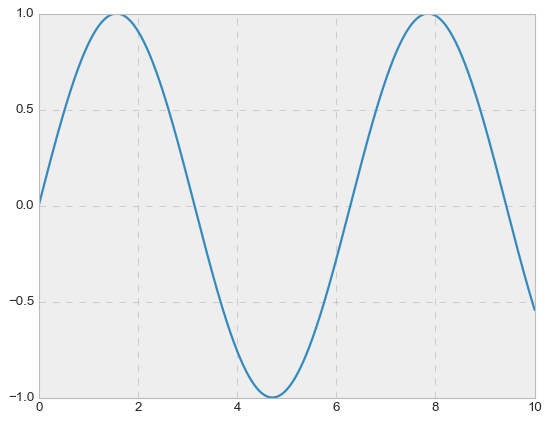

In [47]:
fig = plt.figure()
ax = plt.axes()

x = np.linspace(0, 10, 1000)
ax.plot(x, np.sin(x));

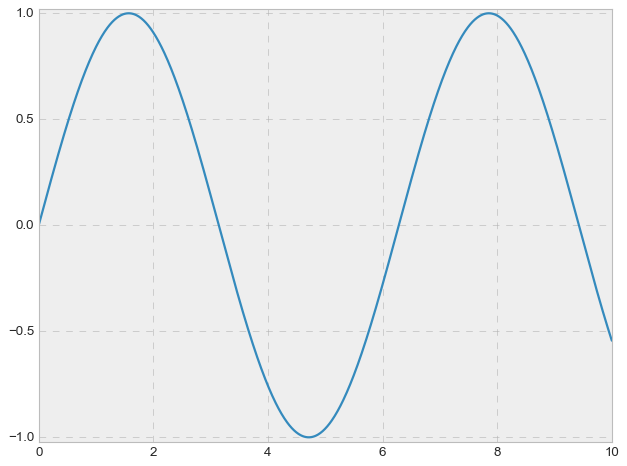

In [57]:
fig = plt.figure()
ax = plt.axes()
x = np.linspace(0, 10, 1000)
ax.plot(x, np.sin(x))
ax.margins(y=0.01)

fig.tight_layout();

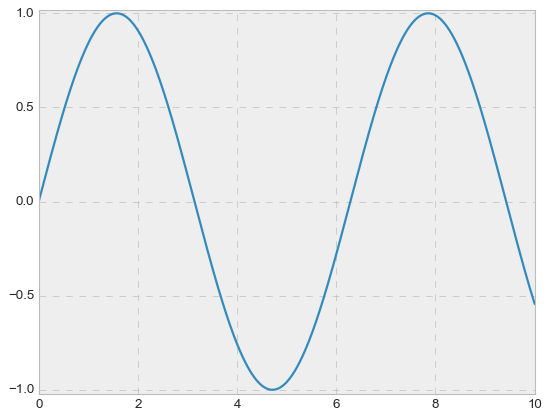

In [60]:
plt.plot(x, np.sin(x))
plt.margins(y=0.01);

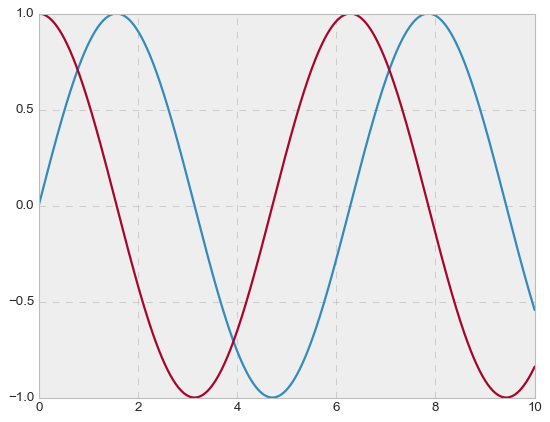

In [61]:
plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x));

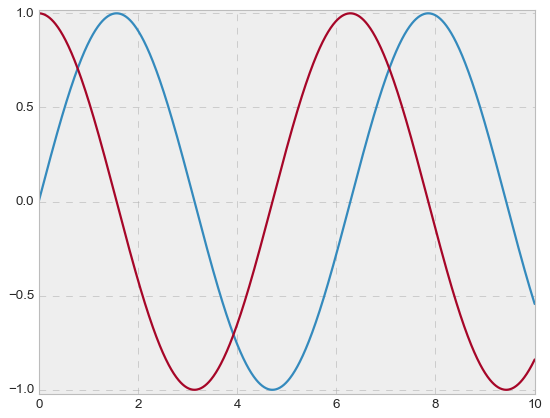

In [69]:
fig = plt.figure()
ax = plt.axes()

ax.plot(x, np.sin(x))
ax.plot(x, np.cos(x))

ax.margins(y=0.01)
plt.show()

## Adjusting the Plot: Line Colors and Styles

The first adjustment you might wish to make to a plot is to control the line colors and styles.
The ``plt.plot()`` function takes additional arguments that can be used to specify these.
To adjust the color, you can use the ``color`` keyword, which accepts a string argument representing virtually any imaginable color.
The color can be specified in a variety of ways:   

[Colors in matplotlib](https://matplotlib.org/stable/gallery/color/named_colors.html)


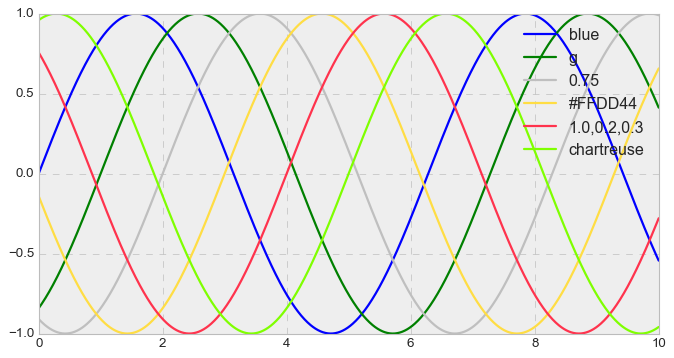

In [83]:
plt.figure(figsize=(10,5))
plt.plot(x, np.sin(x - 0), color='blue', label='blue')        # specify color by name
plt.plot(x, np.sin(x - 1), color='g', label='g')           # short color code (rgbcmyk)
plt.plot(x, np.sin(x - 2), color='0.75', label='0.75')        # Grayscale between 0 and 1
plt.plot(x, np.sin(x - 3), color='#FFDD44', label='#FFDD44')     # Hex code (RRGGBB from 00 to FF)
plt.plot(x, np.sin(x - 4), color=(1.0,0.2,0.3), label=("1.0,0.2,0.3")) # RGB tuple, values 0 to 1
plt.plot(x, np.sin(x - 5), color='chartreuse', label='chartreuse') # all HTML color names supported
ax.margins(y=0.01)
plt.legend();

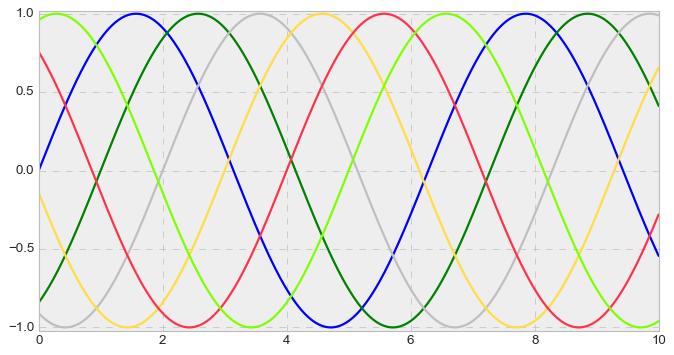

In [75]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x, np.sin(x - 0), color='blue')        # specify color by name
ax.plot(x, np.sin(x - 1), color='g')           # short color code (rgbcmyk)
ax.plot(x, np.sin(x - 2), color='0.75')        # Grayscale between 0 and 1
ax.plot(x, np.sin(x - 3), color='#FFDD44')     # Hex code (RRGGBB from 00 to FF)
ax.plot(x, np.sin(x - 4), color=(1.0,0.2,0.3)) # RGB tuple, values 0 to 1
ax.plot(x, np.sin(x - 5), color='chartreuse'); # all HTML color names supported
ax.margins(y=0.01)

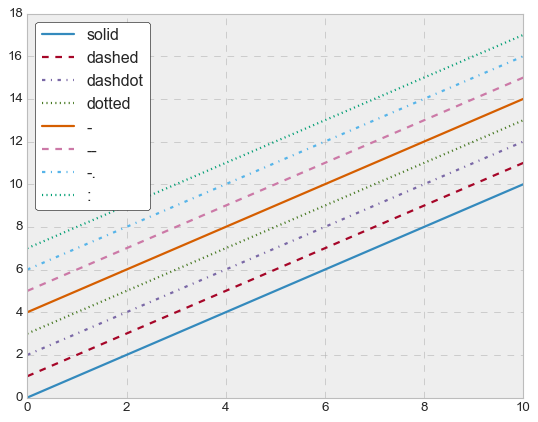

In [88]:
plt.plot(x, x + 0, linestyle='solid', label="solid")
plt.plot(x, x + 1, linestyle='dashed', label='dashed')
plt.plot(x, x + 2, linestyle='dashdot', label='dashdot')
plt.plot(x, x + 3, linestyle='dotted', label='dotted');

# For short, you can use the following codes:
plt.plot(x, x + 4, linestyle='-', label='-')  # solid
plt.plot(x, x + 5, linestyle='--', label='--') # dashed
plt.plot(x, x + 6, linestyle='-.', label='-.') # dashdot
plt.plot(x, x + 7, linestyle=':', label=':')  # dotted

plt.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="black"
);

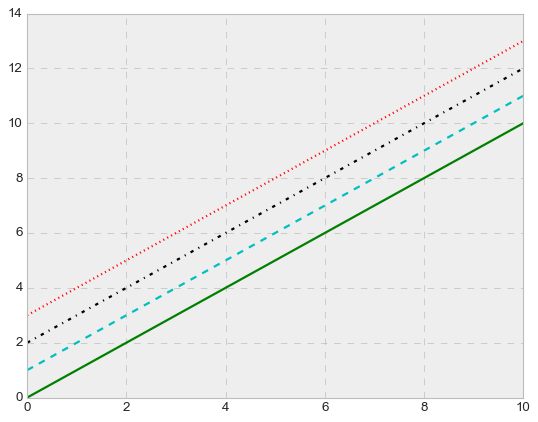

In [89]:
plt.plot(x, x + 0, '-g')  # solid green
plt.plot(x, x + 1, '--c') # dashed cyan
plt.plot(x, x + 2, '-.k') # dashdot black
plt.plot(x, x + 3, ':r');  # dotted red

## Adjusting the Plot: Axes Limits

Matplotlib does a decent job of choosing default axes limits for your plot, but sometimes it's nice to have finer control.
The most basic way to adjust axis limits is to use the ``plt.xlim()`` and ``plt.ylim()`` methods:

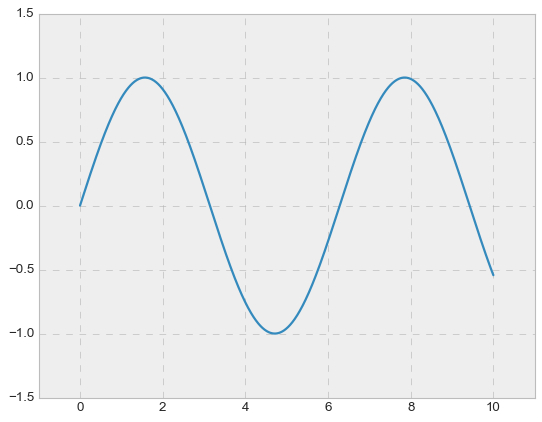

In [90]:
plt.plot(x, np.sin(x))

plt.xlim(-1, 11)
plt.ylim(-1.5, 1.5);

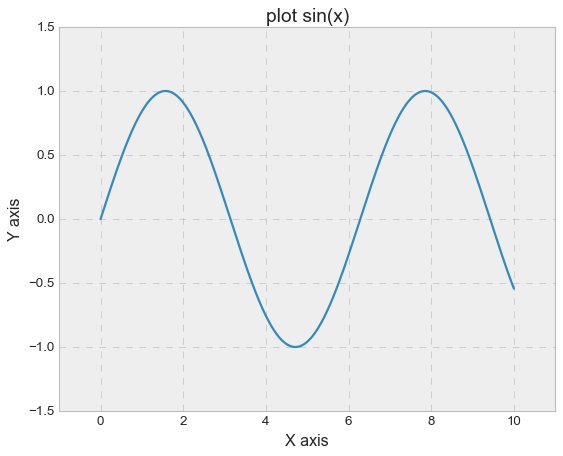

In [101]:
fig, ax = plt.subplots()

ax.plot(x, np.sin(x))
ax.set_xlim(-1, 11)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_title("plot sin(x)");


If for some reason you'd like either axis to be displayed in reverse, you can simply reverse the order of the arguments:

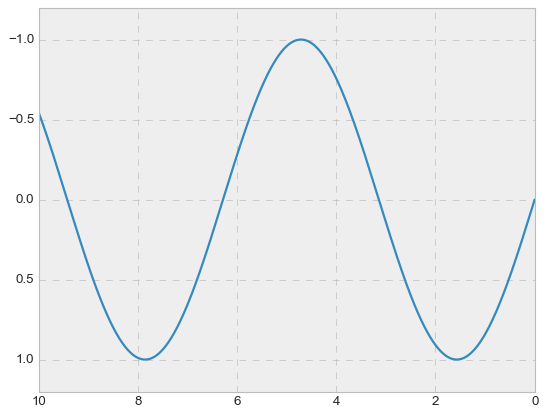

In [ ]:
plt.plot(x, np.sin(x))

plt.xlim(10, 0) # (0, 10) -> (10, 0)
plt.ylim(1.2, -1.2);

A useful related method is ``plt.axis()`` (note here the potential confusion between *axes* with an *e*, and *axis* with an *i*).
The ``plt.axis()`` method allows you to set the ``x`` and ``y`` limits with a single call, by passing a list which specifies ``[xmin, xmax, ymin, ymax]``:

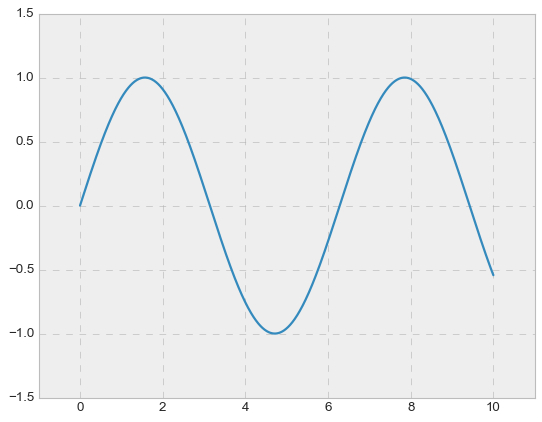

In [103]:
plt.plot(x, np.sin(x))
plt.axis([-1, 11, -1.5, 1.5]);

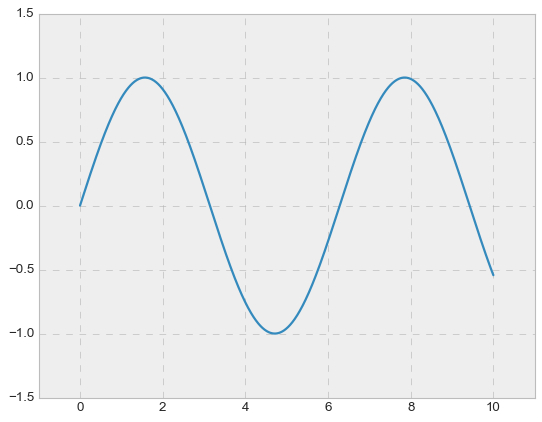

In [114]:
fig = plt.figure()
ax =plt.axes()
ax.plot(x, np.sin(x))
ax.axis([-1, 11, -1.5, 1.5]);

It allows even higher-level specifications, such as ensuring an equal aspect ratio so that on your screen, one unit in ``x`` is equal to one unit in ``y``:

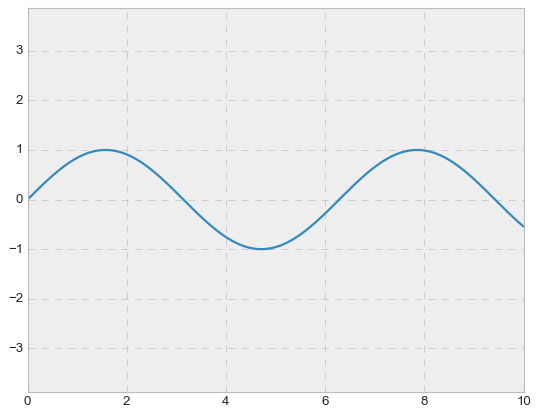

In [116]:
plt.plot(x, np.sin(x))
plt.axis('equal');